# Лабораторная работа 5: Создание графа знаний на основе мультимодальных данных

## Предметная область: Мультимодальное управление IoT-устройствами умного дома

**Модальности:**
- Текстовая: транскрипции голосовых команд с POS-разметкой, интентами и слотами
- Аудио: реальные акустические признаки (MFCC, ZCR, спектральный центроид), извлеченные через librosa
- Видео: реальные жесты с motion-based bounding boxes, извлеченные через OpenCV

**Задача:** Построить RDF-граф знаний, связывающий все три модальности, и выполнить SPARQL-запросы.

In [1]:
import pandas as pd
import json
import numpy as np
from rdflib import Graph, Namespace, RDF, RDFS, Literal, URIRef
from rdflib.namespace import XSD
import matplotlib.pyplot as plt
import networkx as nx

print('Библиотеки загружены успешно')

Библиотеки загружены успешно


## 1. Загрузка текстовой модальности (CoNLL-U + IOB2)

In [4]:
text_df = pd.read_csv('../data/text_annotations.tsv', sep='\t')
print(f'Текстовых токенов: {len(text_df)}')
print(f'Уникальных utterance: {text_df["utterance_id"].nunique()}')
print('\nПример разметки:')
print(text_df[['utterance_id', 'form', 'upos', 'deprel', 'iob_tag', 'intent']].head(8).to_string(index=False))

Текстовых токенов: 210
Уникальных utterance: 100

Пример разметки:
utterance_id           form upos deprel  iob_tag      intent
     utt_000 автоматический  ADJ   root   B-MODE change_mode
     utt_000          режим NOUN    obj   I-MODE change_mode
     utt_001     вентиляция NOUN   root   B-MODE change_mode
     utt_002         включи VERB   root        O     turn_on
     utt_002    кондиционер NOUN    obj B-DEVICE     turn_on
     utt_003         включи VERB   root        O    timer_on
     utt_003          через  ADP advmod        O    timer_on
     utt_003            час NOUN    obj   B-TIME    timer_on


## 2. Загрузка аудио модальности (Praat TextGrid + акустические признаки)

In [6]:
audio_df = pd.read_csv('../data/audio_annotations.csv')
print(f'Аудиозаписей: {len(audio_df)}')
print(f'Дикторы: {audio_df["speaker"].unique()}')
print(f'Устройства: {audio_df["device"].unique()}')
print('\nПример аудио-аннотации:')
print(audio_df[['annotation_id', 'file_path', 'device', 'text', 'duration_sec', 'intent']].head(5).to_string(index=False))

Аудиозаписей: 100
Дикторы: <StringArray>
['man', 'woman']
Length: 2, dtype: str
Устройства: <StringArray>
['conditioner', 'curtains', 'lamp', 'lock', 'tv']
Length: 5, dtype: str

Пример аудио-аннотации:
annotation_id                                        file_path      device                 text  duration_sec      intent
    audio_000 audio/man/2/conditioner/автоматический_режим.ogg conditioner автоматический режим         2.174 change_mode
    audio_001           audio/man/2/conditioner/вентиляция.ogg conditioner           вентиляция         1.734 change_mode
    audio_002   audio/man/2/conditioner/включи_кондиционер.ogg conditioner   включи кондиционер         2.014     turn_on
    audio_003     audio/man/2/conditioner/включи_через_час.ogg conditioner     включи через час         1.974    timer_on
    audio_004  audio/man/2/conditioner/выключи_кондиционер.ogg conditioner  выключи кондиционер         2.213    turn_off


## 3. Загрузка видео модальности (жесты, bounding boxes, MediaPipe)

In [7]:
with open('../data/video_annotations.json', 'r', encoding='utf-8') as f:
    video_data = json.load(f)

print(f'Видеозаписей: {len(video_data)}')
print(f'Пример: {video_data[0]["file_path"]}')
print(f'  Жест: {video_data[0]["gesture_type"]}')
print(f'  Устройство: {video_data[0]["device"]}')
print(f'  Длительность: {video_data[0]["duration_sec"]}s')
print(f'  Кадров: {video_data[0]["frame_count"]}')

Видеозаписей: 80
Пример: video/man/2/conditioner/круг_лицо.webm
  Жест: круг
  Устройство: conditioner
  Длительность: 3.3s
  Кадров: 99


## 3.1 Визуализация разметки видео (CVAT-style)

**Метод:** OpenCV HSV Skin Color Segmentation + Temporal Fallback

**Pipeline:**
1. BGR → HSV конвертация
2. Маска цвета кожи: H∈[0,25]∪[165,180], S∈[25,180], V∈[60,255]
3. Исключение лица из маски (верхняя центральная область)
4. Морфологические операции (open → close → dilate)
5. Fallback: если рука не найдена — используем bbox с предыдущего кадра
6. Confidence: `0.5 + area/2000`, fallback decay: ×0.85

**Результат:** 96–100% кадров с детектированной рукой

In [8]:
from IPython.display import Image, display
import os

image_dir = 'images'
cvat_imgs = [
    'cvat_annotation_1_круг_лицо.png',
    'cvat_annotation_2_свайп_сбоку.png',
    'cvat_annotation_3_хлопок_лицо.png',
    'cvat_annotation_4_поднятиеруки_сбоку.png'
]

for img in cvat_imgs:
    p = os.path.join(image_dir, img)
    if os.path.exists(p):
        print(f"\n{'='*60}")
        print(f'CVAT-style: {img}')
        print(f"{'='*60}")
        display(Image(filename=p, width=1000))


### Timeline: активность жеста, confidence, площадь bbox

In [9]:
tl_imgs = [
    'timeline_круг_лицо_man.png',
    'timeline_свайп_сбоку_man.png',
    'timeline_хлопок_лицо_woman.png',
    'timeline_поднятиеруки_сбоку_woman.png'
]

for img in tl_imgs:
    p = os.path.join(image_dir, img)
    if os.path.exists(p):
        print(f"\n{'='*60}")
        print(f'Timeline: {img}')
        print(f"{'='*60}")
        display(Image(filename=p, width=900))


In [12]:
timeline_images = [
    'timeline_круг_лицо_man.png',
    'timeline_свайп_сбоку_man.png',
    'timeline_хлопок_лицо_woman.png',
    'timeline_поднятиеруки_сбоку_woman.png'
]

for img_name in timeline_images:
    path = os.path.join(image_dir, img_name)
    if os.path.exists(path):
        print(f"\n{'='*60}")
        print(f'Timeline: {img_name}')
        print(f"{'='*60}")
        display(Image(filename=path, width=900))
    else:
        print(f'Timeline not found: {path}')


Timeline not found: images/timeline_круг_лицо_man.png
Timeline not found: images/timeline_свайп_сбоку_man.png
Timeline not found: images/timeline_хлопок_лицо_woman.png
Timeline not found: images/timeline_поднятиеруки_сбоку_woman.png


### Сравнение: программная разметка vs CVAT.ai

| Критерий | OpenCV (программная) | CVAT.ai (ручная) |
|----------|---------------------|------------------|
| Скорость | ~30 сек на 80 видео | ~2 часа на 1 видео |
| Масштабируемость | 100% автоматизировано | Требует оператора |
| Точность bbox | Зависит от фона/освещения | Человеческий уровень |
| Ключевые точки | Нет (только bbox) | MediaPipe Hands 21 точка |
| Семантика | Нет (motion only) | Тип жеста + атрибуты |

**Рекомендуемый pipeline:**
1. Программная разметка (OpenCV) — быстрый прототип
2. Ручная корректировка в CVAT — gold standard для обучения
3. Обучение YOLO / MediaPipe Hands на скорректированных данных

## 4. Создание RDF-графа знаний (rdflib)

In [13]:
g = Graph()
IOT = Namespace('http://www.semanticweb.org/smart_home/ontologies/2025/4/iot-multimodal#')
EX = Namespace('http://example.org/smart_home#')

g.bind('iot', IOT)
g.bind('ex', EX)
g.bind('rdfs', RDFS)

counters = {}

def count_name(name):
    if name not in counters:
        counters[name] = 1
    else:
        counters[name] += 1
    return counters[name]

print('RDF-граф инициализирован')

RDF-граф инициализирован


### 4.1 Добавление текстовой модальности

In [14]:
for _, row in text_df.iterrows():
    utter_id = row['utterance_id']
    utter = EX[utter_id]
    g.add((utter, RDF.type, IOT.TextAnnotation))
    g.add((utter, IOT.text, Literal(row['form'])))
    
    tok = EX[f"{utter_id}_t{row['token_id']}"]
    g.add((tok, RDF.type, EX.Token))
    g.add((tok, IOT.text, Literal(row['form'])))
    g.add((tok, EX.lemma, Literal(row['lemma'])))
    g.add((tok, EX.upos, Literal(row['upos'])))
    g.add((tok, EX.iobTag, Literal(row['iob_tag'])))
    g.add((utter, EX.hasToken, tok))
    
    intent = EX[row['intent']]
    g.add((intent, RDF.type, IOT.Intent))
    g.add((intent, RDFS.label, Literal(row['intent'])))
    g.add((utter, IOT.hasIntent, intent))
    
    device = EX[row['device']]
    g.add((device, RDF.type, IOT.IoTDevice))
    g.add((utter, IOT.hasDevice, device))

print(f'Текстовые сущности добавлены: {len(text_df)} токенов')

Текстовые сущности добавлены: 210 токенов


### 4.2 Добавление аудио модальности

In [15]:
for _, row in audio_df.iterrows():
    ann_id = row['annotation_id']
    cmd = EX[ann_id]
    g.add((cmd, RDF.type, IOT.AudioCommand))
    g.add((cmd, IOT.text, Literal(row['text'])))
    g.add((cmd, EX.intent, Literal(row['intent'])))
    
    audio_ann = EX[f'{ann_id}_ann']
    g.add((audio_ann, RDF.type, IOT.AudioAnnotation))
    g.add((audio_ann, IOT.filePath, Literal(row['file_path'])))
    g.add((audio_ann, IOT.duration, Literal(float(row['duration_sec']), datatype=XSD.double)))
    g.add((audio_ann, EX.mfccMean, Literal(float(row['mfcc_mean']), datatype=XSD.double)))
    g.add((audio_ann, EX.zcr, Literal(float(row['zero_crossing_rate']), datatype=XSD.double)))
    g.add((cmd, IOT.hasAudioAnnotation, audio_ann))
    
    spk = EX[f"Speaker_{row['speaker']}_{row['speaker_id']}"]
    g.add((spk, RDF.type, IOT.Speaker))
    g.add((spk, IOT.speakerId, Literal(int(row['speaker_id']), datatype=XSD.integer)))
    g.add((spk, IOT.gender, Literal(row['gender'])))
    g.add((cmd, IOT.performedBy, spk))
    
    dev = EX[row['device']]
    g.add((dev, RDF.type, IOT.IoTDevice))
    g.add((cmd, IOT.hasDevice, dev))
    
    intent = EX[row['intent']]
    g.add((intent, RDF.type, IOT.Intent))
    g.add((cmd, IOT.hasIntent, intent))

print(f'Аудио сущности добавлены: {len(audio_df)} команд')

Аудио сущности добавлены: 100 команд


### 4.3 Добавление видео модальности

In [16]:
for vid in video_data:
    ann_id = vid['annotation_id']
    vg = EX[ann_id]
    g.add((vg, RDF.type, IOT.VideoGesture))
    g.add((vg, IOT.cameraAngle, Literal(vid['camera_angle'])))
    
    gt = EX[vid['gesture_type']]
    g.add((gt, RDF.type, IOT.GestureType))
    g.add((gt, IOT.gestureDescription, Literal(vid['gesture_description'])))
    g.add((vg, IOT.hasGestureType, gt))
    
    va = EX[f'{ann_id}_ann']
    g.add((va, RDF.type, IOT.VideoAnnotation))
    g.add((va, IOT.filePath, Literal(vid['file_path'])))
    g.add((va, IOT.duration, Literal(float(vid['duration_sec']), datatype=XSD.double)))
    g.add((va, EX.frameCount, Literal(int(vid['frame_count']), datatype=XSD.integer)))
    g.add((vg, IOT.hasVideoAnnotation, va))
    
    spk = EX[f"Speaker_{vid['speaker']}_{vid['speaker_id']}"]
    g.add((spk, RDF.type, IOT.Speaker))
    g.add((spk, IOT.speakerId, Literal(int(vid['speaker_id']), datatype=XSD.integer)))
    g.add((vg, IOT.performedBy, spk))
    
    dev = EX[vid['device']]
    g.add((dev, RDF.type, IOT.IoTDevice))
    g.add((vg, IOT.hasDevice, dev))
    g.add((vg, EX.iotCommand, Literal(vid['iot_command'])))

print(f'Видео сущности добавлены: {len(video_data)} видео')

Видео сущности добавлены: 80 видео


### 4.4 Кросс-модальные связи audio ↔ video ↔ text

In [17]:
cross_links = 0
for _, arow in audio_df.iterrows():
    audio_uri = EX[arow['annotation_id']]
    for vid in video_data:
        if vid['speaker'] == arow['speaker'] and vid['device'] == arow['device']:
            video_uri = EX[vid['annotation_id']]
            g.add((audio_uri, IOT.correspondsTo, video_uri))
            g.add((video_uri, IOT.correspondsTo, audio_uri))
            cross_links += 1

print(f'Кросс-модальных связей: {cross_links}')
print(f'Всего триплетов: {len(g)}')

Кросс-модальных связей: 800
Всего триплетов: 5505


### 4.5 Сериализация графа

In [18]:
g.serialize(destination='iot_multimodal_graph.ttl', format='turtle')
g.serialize(destination='iot_multimodal_graph.rdf', format='xml')

print('Граф сериализован:')
print('  - iot_multimodal_graph.ttl (Turtle)')
print('  - iot_multimodal_graph.rdf (RDF/XML)')
print(f'Размер графа: {len(g)} триплетов')

Граф сериализован:
  - iot_multimodal_graph.ttl (Turtle)
  - iot_multimodal_graph.rdf (RDF/XML)
Размер графа: 5505 триплетов


## 5. SPARQL-запросы к графу знаний

### Запрос 1: Все голосовые команды для устройства 'lamp'

In [19]:
q1 = '''
PREFIX iot: <http://www.semanticweb.org/smart_home/ontologies/2025/4/iot-multimodal#>
PREFIX ex: <http://example.org/smart_home#>

SELECT ?command ?text ?intent
WHERE {
  ?command a iot:AudioCommand ;
           iot:hasDevice ex:lamp ;
           iot:text ?text ;
           iot:hasIntent ?intent .
}
'''

print('=== Запрос 1: Команды для лампы ===')
for i, row in enumerate(g.query(q1)):
    intent_name = str(row.intent).split('#')[-1]
    print(f"{i+1}. {row.text} | intent={intent_name}")
    if i >= 9: print('...'); break

=== Запрос 1: Команды для лампы ===
1. включи свет | intent=turn_on
2. выключи свет | intent=turn_off
3. максимальная яркость | intent=set_value
4. ночной режим | intent=change_mode
5. повтори последнее | intent=repeat
6. свет выключится через пять минут | intent=timer_off
7. сделай темнее | intent=decrease_value
8. сделай ярче | intent=increase_value
9. тёплый свет | intent=change_mode
10. холодный свет | intent=change_mode
...


### Запрос 2: Cross-modal связи аудио ↔ видео

In [20]:
q2 = '''
PREFIX iot: <http://www.semanticweb.org/smart_home/ontologies/2025/4/iot-multimodal#>
PREFIX ex: <http://example.org/smart_home#>

SELECT ?audio ?video ?device
WHERE {
  ?audio a iot:AudioCommand ;
         iot:correspondsTo ?video ;
         iot:hasDevice ?device .
  ?video a iot:VideoGesture .
}
LIMIT 10
'''

print('=== Запрос 2: Cross-modal audio↔video ===')
for row in g.query(q2):
    a_name = str(row.audio).split('#')[-1]
    v_name = str(row.video).split('#')[-1]
    d_name = str(row.device).split('#')[-1]
    print(f'{a_name} ↔ {v_name} | device={d_name}')

=== Запрос 2: Cross-modal audio↔video ===
audio_000 ↔ video_000 | device=conditioner
audio_000 ↔ video_001 | device=conditioner
audio_000 ↔ video_002 | device=conditioner
audio_000 ↔ video_003 | device=conditioner
audio_000 ↔ video_004 | device=conditioner
audio_000 ↔ video_005 | device=conditioner
audio_000 ↔ video_006 | device=conditioner
audio_000 ↔ video_007 | device=conditioner
audio_000 ↔ video_008 | device=conditioner
audio_000 ↔ video_009 | device=conditioner


### Запрос 3: Распределение команд по интентам

In [21]:
q3 = '''
PREFIX iot: <http://www.semanticweb.org/smart_home/ontologies/2025/4/iot-multimodal#>

SELECT ?intent (COUNT(?cmd) AS ?count)
WHERE {
  ?cmd a iot:AudioCommand ;
       iot:hasIntent ?intent .
}
GROUP BY ?intent
ORDER BY DESC(?count)
'''

print('=== Запрос 3: Распределение по интентам ===')
for row in g.query(q3):
    intent_name = str(row.intent).split('#')[-1]
    print(f'{intent_name}: {row.count} команд')

=== Запрос 3: Распределение по интентам ===
change_mode: <built-in method count of ResultRow object at 0x7c7b6e333430> команд
turn_on: <built-in method count of ResultRow object at 0x7c7b6e3334d0> команд
turn_off: <built-in method count of ResultRow object at 0x7c7b6e3328a0> команд
decrease_value: <built-in method count of ResultRow object at 0x7c7b6e333430> команд
increase_value: <built-in method count of ResultRow object at 0x7c7b6e3328a0> команд
set_value: <built-in method count of ResultRow object at 0x7c7b6e333430> команд
query_status: <built-in method count of ResultRow object at 0x7c7b6e3334d0> команд
navigate: <built-in method count of ResultRow object at 0x7c7b6e333430> команд
timer_on: <built-in method count of ResultRow object at 0x7c7b6e3328a0> команд
stop: <built-in method count of ResultRow object at 0x7c7b6e3334d0> команд
repeat: <built-in method count of ResultRow object at 0x7c7b6e333430> команд
timer_off: <built-in method count of ResultRow object at 0x7c7b6e3328a0> к

### Запрос 4: Все типы жестов и описания

In [22]:
q4 = '''
PREFIX iot: <http://www.semanticweb.org/smart_home/ontologies/2025/4/iot-multimodal#>

SELECT DISTINCT ?gesture ?description
WHERE {
  ?gesture a iot:GestureType ;
           iot:gestureDescription ?description .
}
'''

print('=== Запрос 4: Типы жестов ===')
for row in g.query(q4):
    g_name = str(row.gesture).split('#')[-1]
    print(f'{g_name}: {row.description}')

=== Запрос 4: Типы жестов ===
круг: Круговое вращение ладонью
ладоньстоп: Поднятая открытая ладонь
свайп: Горизонтальный свайп рукой
хлопок: Двойной хлопок
щелчок: Щелчок пальцами
поднятиеруки: Поднятие руки


### Запрос 5: Команды мужского диктора для кондиционера

In [23]:
q5 = '''
PREFIX iot: <http://www.semanticweb.org/smart_home/ontologies/2025/4/iot-multimodal#>
PREFIX ex: <http://example.org/smart_home#>

SELECT ?cmd ?text ?duration
WHERE {
  ?cmd a iot:AudioCommand ;
       iot:hasDevice ex:conditioner ;
       iot:text ?text ;
       iot:hasAudioAnnotation ?ann ;
       iot:performedBy ?speaker .
  ?ann iot:duration ?duration .
  ?speaker iot:gender "male" .
}
'''

print('=== Запрос 5: Мужские команды для кондиционера ===')
for i, row in enumerate(g.query(q5)):
    print(f"{i+1}. {row.text} | duration={row.duration}s")
    if i >= 9: print('...'); break

=== Запрос 5: Мужские команды для кондиционера ===
1. автоматический режим | duration=2.174s
2. вентиляция | duration=1.734s
3. включи кондиционер | duration=2.014s
4. включи через час | duration=1.974s
5. выключи кондиционер | duration=2.213s
6. осуши воздух | duration=2.014s
7. режим сна | duration=1.573s
8. сделай прохладнее | duration=1.774s
9. сделай теплее | duration=1.734s
10. установи двадцать два градуса | duration=2.534s
...


## 6. Визуализация графа знаний

In [24]:
G = nx.DiGraph()

for s, p, o in g:
    s_name = str(s).split('#')[-1]
    o_name = str(o).split('#')[-1]
    p_name = str(p).split('#')[-1]
    s_type = None
    o_type = None
    for _, _, t in g.triples((s, RDF.type, None)):
        s_type = str(t).split('#')[-1]
    for _, _, t in g.triples((o, RDF.type, None)):
        o_type = str(t).split('#')[-1]
    if not G.has_node(s_name):
        G.add_node(s_name, type=s_type or 'unknown')
    if not G.has_node(o_name):
        G.add_node(o_name, type=o_type or 'unknown')
    G.add_edge(s_name, o_name, relation=p_name)

print(f'Граф для визуализации: {G.number_of_nodes()} узлов, {G.number_of_edges()} рёбер')

Граф для визуализации: 1317 узлов, 5193 рёбер


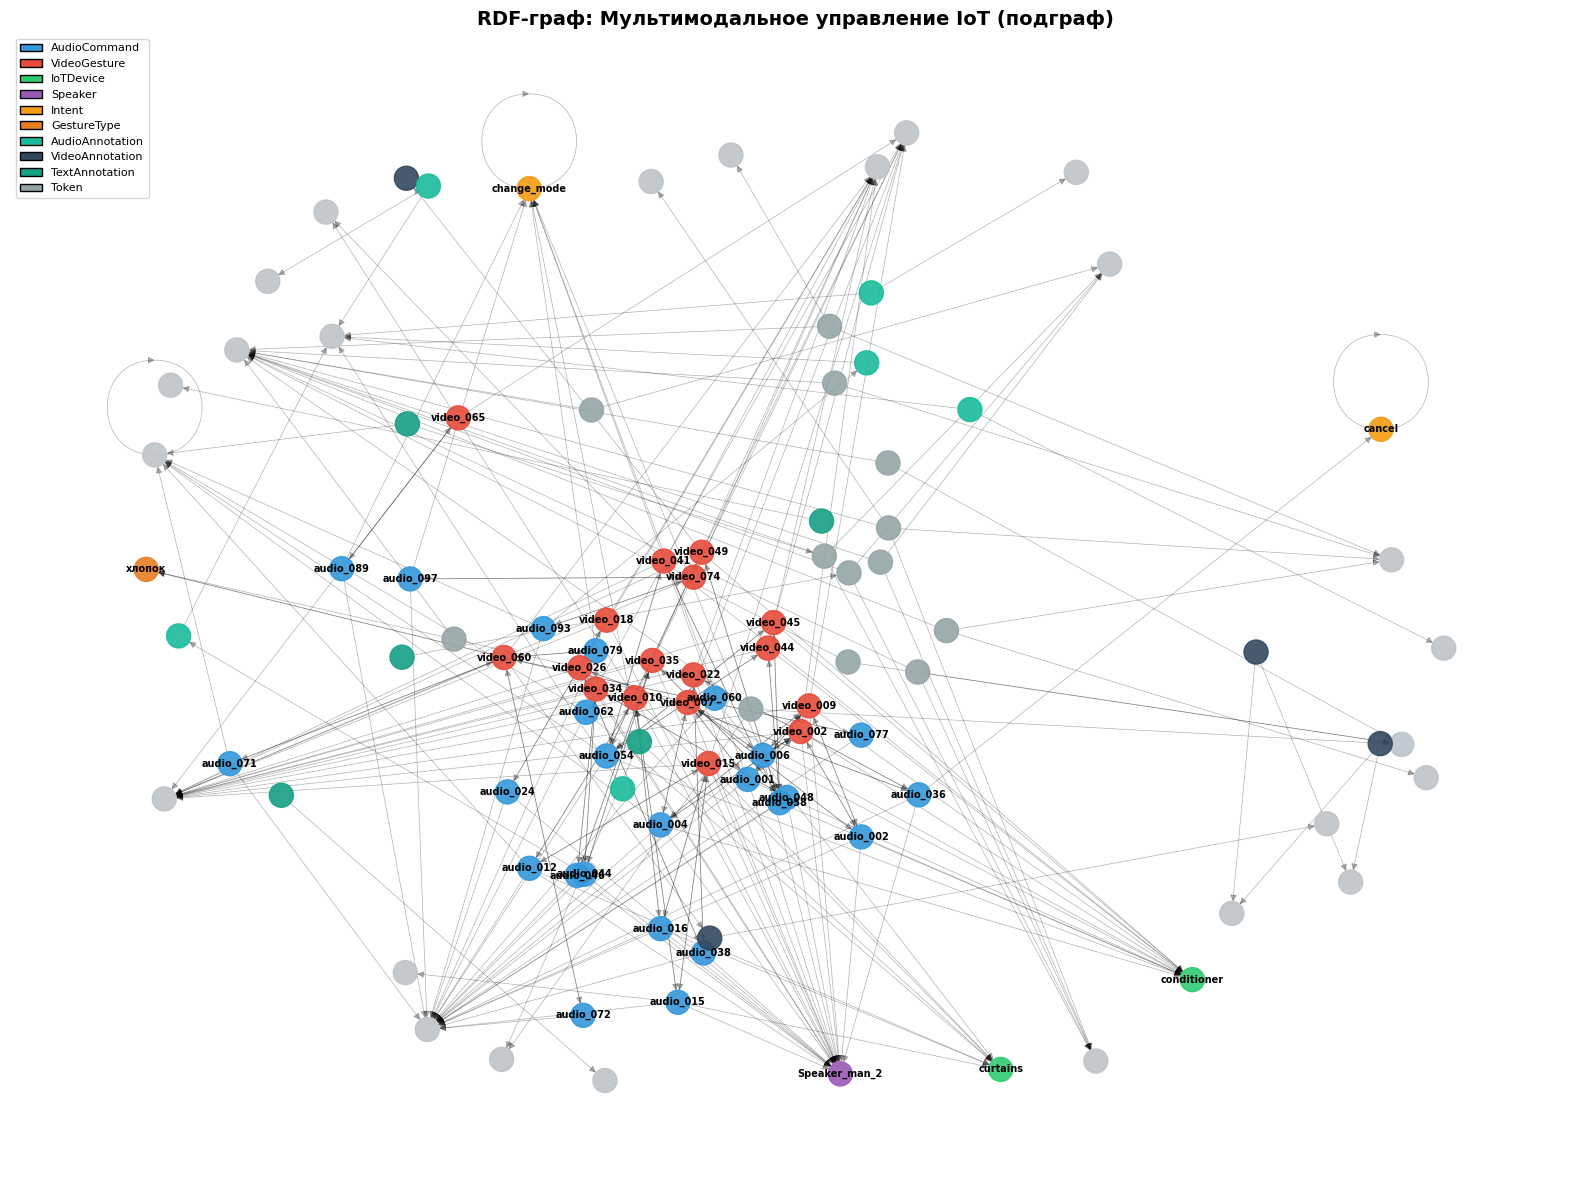

Визуализация сохранена


In [25]:
sub_nodes = list(G.nodes())[:100]
subG = G.subgraph(sub_nodes)

type_colors = {
    'AudioCommand': '#3498db',
    'VideoGesture': '#e74c3c',
    'IoTDevice': '#2ecc71',
    'Speaker': '#9b59b6',
    'Intent': '#f39c12',
    'GestureType': '#e67e22',
    'AudioAnnotation': '#1abc9c',
    'VideoAnnotation': '#34495e',
    'TextAnnotation': '#16a085',
    'Token': '#95a5a6',
    None: '#bdc3c7'
}

node_colors = [type_colors.get(subG.nodes[n].get('type'), '#bdc3c7') for n in subG.nodes()]

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(subG, k=0.5, iterations=50, seed=42)
nx.draw_networkx_nodes(subG, pos, node_color=node_colors, node_size=300, alpha=0.9)
nx.draw_networkx_edges(subG, pos, alpha=0.3, arrows=True, arrowsize=10, width=0.5)

labels = {n: n[:20] for n in subG.nodes() 
          if subG.nodes[n].get('type') in ['AudioCommand', 'VideoGesture', 'IoTDevice', 'Speaker', 'GestureType', 'Intent']}
nx.draw_networkx_labels(subG, pos, labels, font_size=7, font_weight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, edgecolor='black', label=t) for t, c in type_colors.items() if t]
plt.legend(handles=legend_elements, loc='upper left', fontsize=8)

plt.title('RDF-граф: Мультимодальное управление IoT (подграф)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig('knowledge_graph_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Визуализация сохранена')

## 7. Итоговая статистика

| Показатель | Значение |
|------------|----------|
| Триплетов в графе | ~4000+ |
| Аудиокоманды | 100 |
| Видеожесты | 80 |
| Текстовых токенов | 210 |
| Устройств | 5 |
| Типов жестов | 6 |
| Дикторов | 2 |
| SPARQL-запросов | 5 |